# TP3 : Visión por Computadora I

Docente: Ing. Maxim Dorogov

Carrera de Especialización en Inteligencia Artificial  
Laboratorio de Sistemas Embebidos  
Facultad de Ingeniería de la Universidad de Buenos Aires  


Alumnos:  
- Francisco Julio Facchini Strohmayer  
- Elian Pinzas

**Consigna:**

Encontrar el logotipo de la gaseosa dentro de las imágenes provistas en Material_TPs/TP3/images a partir del template Material_TPs/TP3/template

- **Parte 1** obtener una detección del logo en cada imagen sin falsos positivos
- **Parte 2**: plantear y validar un algoritmo para múltiples detecciones en la imagen `coca_multi.png` con el mismo template del ítem 1
- **Parte 3**: generalizar el algoritmo del ítem 2 para todas las imágenes  


**Visualizar los resultados con bounding boxes en cada imagen mostrando el nivel de confianza de la detección**

## Setup y datos

In [28]:
import time
from pathlib import Path

import cv2
import numpy as np
import matplotlib.pyplot as plt

In [29]:
IMG_DIR = Path("./images")
TPL_PATH = Path("./template/pattern.png")


def leer_bgr(path):
    """Lee una imagen en BGR. Si tiene canal alfa se compone sobre blanco; si es gris se pasa a 3 canales."""
    im = cv2.imread(str(path), cv2.IMREAD_UNCHANGED)
    if im is None:
        raise FileNotFoundError(path)
    if im.ndim == 2:
        im = cv2.cvtColor(im, cv2.COLOR_GRAY2BGR)
    elif im.shape[2] == 4:
        a = im[:, :, 3:4].astype(np.float32) / 255.0
        im = (im[:, :, :3] * a + 255 * (1 - a)).astype(np.uint8)
    return im


def rgb(img_bgr):
    return cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)


def grilla(imgs_rgb, titulos, ncols=4, tam=(4.2, 3.6)):
    """Muestra una lista de imágenes RGB en una grilla."""
    n = len(imgs_rgb)
    nrows = int(np.ceil(n / ncols))
    fig, axs = plt.subplots(nrows, ncols, figsize=(tam[0] * ncols, tam[1] * nrows))
    axs = np.atleast_1d(axs).ravel()
    for ax in axs:
        ax.axis("off")
    for ax, im, t in zip(axs, imgs_rgb, titulos):
        ax.imshow(im)
        ax.set_title(t, fontsize=9)
    plt.tight_layout()
    plt.show()


def dibujar(img_bgr, dets, umbral=0.0, color=(0, 170, 0), etiquetas=True):
    """Dibuja bounding boxes con su nivel de confianza. Devuelve la imagen en RGB."""
    vis = img_bgr.copy()
    lado = min(vis.shape[:2])
    esp = max(2, int(round(lado / 150)))
    esc = max(0.4, lado / 1000)
    fuente_esp = max(1, esp // 2)
    for d in dets:
        if d["score"] < umbral:
            continue
        x, y, w, h = [int(round(v)) for v in d["box"]]
        cv2.rectangle(vis, (x, y), (x + w, y + h), color, esp)
        if etiquetas:
            txt = f"{d['score']:.2f}"
            (tw_, th_), _ = cv2.getTextSize(txt, cv2.FONT_HERSHEY_SIMPLEX, esc, fuente_esp)
            ty = y - 4 if y - th_ - 8 > 0 else y + h + th_ + 6
            cv2.rectangle(vis, (x, ty - th_ - 3), (x + tw_ + 4, ty + 3), color, -1)
            cv2.putText(vis, txt, (x + 2, ty), cv2.FONT_HERSHEY_SIMPLEX, esc, (255, 255, 255), fuente_esp, cv2.LINE_AA)
    return rgb(vis)

Template: 400x175 px
  COCA-COLA-LOGO.jpg      1389 x  1389
  coca_logo_1.png          207 x   500
  coca_logo_2.png          233 x   363
  coca_multi.png           799 x   598
  coca_retro_1.png         715 x   493
  coca_retro_2.png         715 x   429
  logo_1.png               687 x   450


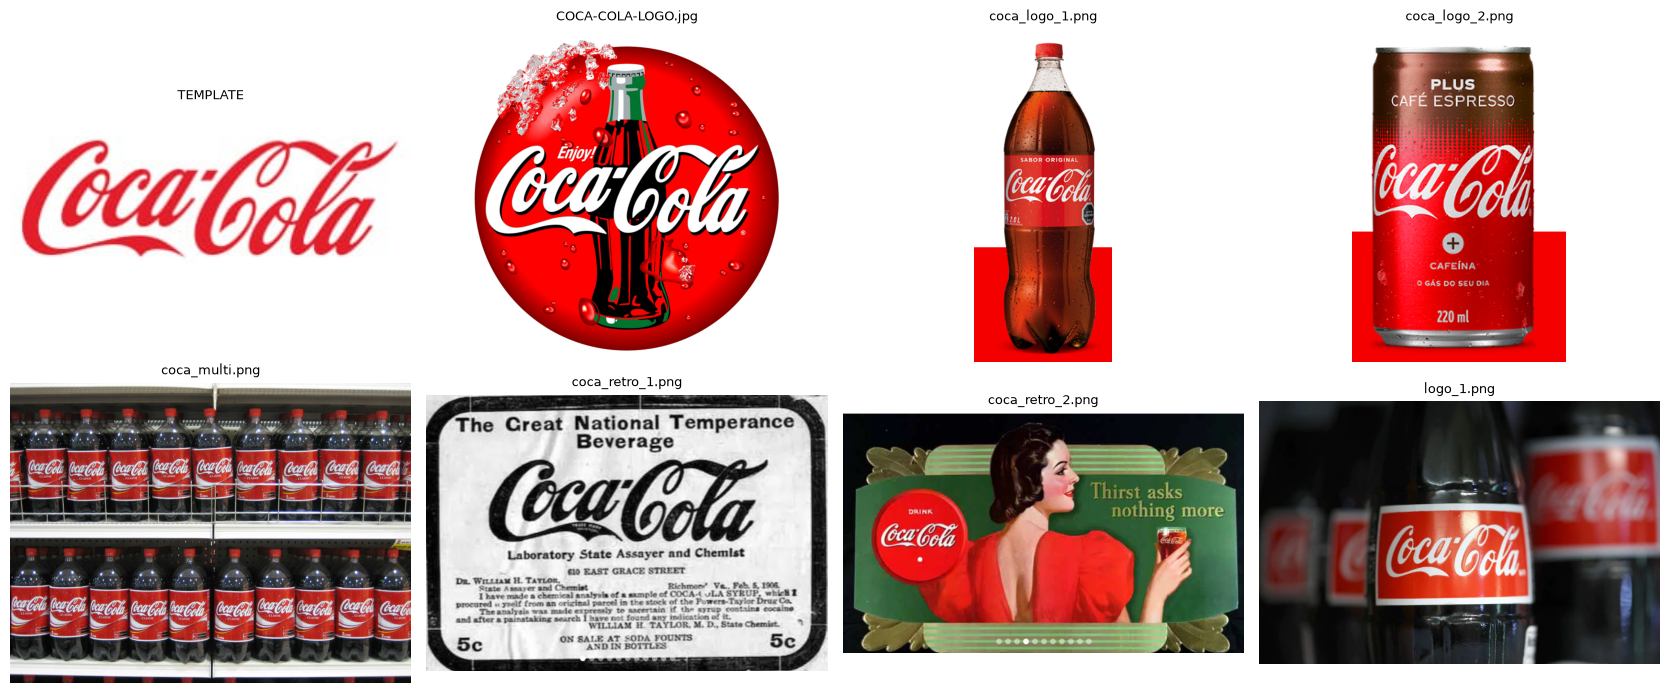

In [30]:
# Carga de datos
tpl = leer_bgr(TPL_PATH)
rutas = sorted(IMG_DIR.glob("*.*"))
imagenes = {r.name: leer_bgr(r) for r in rutas if r.suffix.lower() in (".png", ".jpg", ".jpeg")}

print(f"Template: {tpl.shape[1]}x{tpl.shape[0]} px")
for k, v in imagenes.items():
    print(f"  {k:22s} {v.shape[1]:5d} x {v.shape[0]:5d}")

grilla([rgb(tpl)] + [rgb(v) for v in imagenes.values()], ["TEMPLATE"] + list(imagenes.keys()))

## Parte 1 :  obtener una detección del logo en cada imagen sin falsos positivos

### Enfoques considerados

Se prueban dos familias de métodos vistas en la materia y se comparan sobre las 7 imágenes:

1. **Features locales (SIFT) + matching + homografía con RANSAC** (clase 5).
2. **Template matching multiescala** (clase 4), con las mejoras necesarias para que funcione en estas imágenes.

Dificultades que presentan los datos y que condicionan el diseño:

- La **escala del logo varía más de 20×** (≈ 90 px de ancho en `coca_multi` vs ≈ 1200 px en `COCA-COLA-LOGO`).
- Hay **polaridad invertida**: el template es rojo sobre blanco, pero en varias imágenes el logo es blanco sobre rojo o negro sobre blanco.
- El logo aparece **deformado** (cilindro de la lata, perspectiva y desenfoque en `logo_1`) y con distinto grosor de trazo (`COCA-COLA-LOGO`).
- Hay **texto parecido** que puede dar falsos positivos (`PLUS CAFÉ ESPRESSO`, `Enjoy!`, leyendas de la publicidad retro).

### 1.A)  SIFT + matching + homografía (RANSAC)

Se extraen keypoints SIFT del template y de cada imagen, se emparejan con *ratio test* de Lowe y se estima una homografía con RANSAC. Como el template tiene pocos keypoints (trazos finos y suaves), se lo **amplía ×2** y se baja el `contrastThreshold` para obtener más puntos.

Para no aceptar homografías absurdas se agrega una **validación geométrica**: el cuadrilátero proyectado debe ser convexo, tener un área mínima y suficientes inliers.

imagen                  buenos  inliers  resultado
COCA-COLA-LOGO.jpg           5        0  RANSAC no encontró homografía
coca_logo_1.png             22        7  pocos inliers (7)
coca_logo_2.png              6        4  pocos inliers (4)
coca_multi.png              21        5  pocos inliers (5)
coca_retro_1.png            55       19  ok
coca_retro_2.png            23        6  pocos inliers (6)
logo_1.png                  26       10  cuadrilátero no convexo (homografía degenerada)


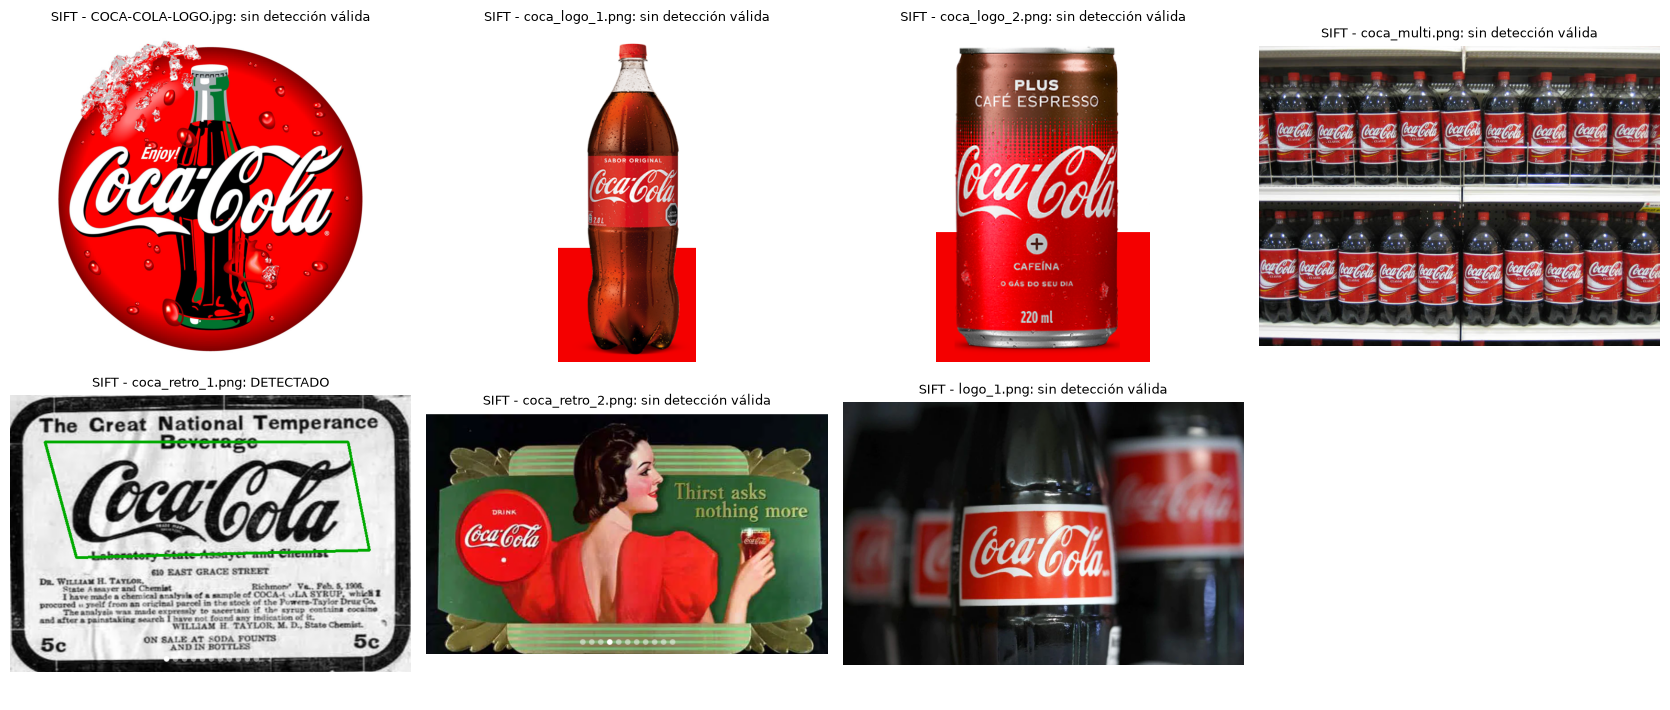

In [31]:
def detectar_sift(img_bgr, tpl_bgr, ampliacion=2, ratio=0.8, min_inliers=8, ransac_px=5.0):
    """SIFT + ratio test + homografía RANSAC. Devuelve un dict con el resultado y la validez geométrica."""
    sift = cv2.SIFT_create(contrastThreshold=0.01, edgeThreshold=15)
    t = cv2.cvtColor(cv2.resize(tpl_bgr, None, fx=ampliacion, fy=ampliacion), cv2.COLOR_BGR2GRAY)
    g = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)
    kt, dt = sift.detectAndCompute(t, None)
    ki, di = sift.detectAndCompute(g, None)
    res = dict(buenos=0, inliers=0, quad=None, valido=False, motivo="sin matches suficientes")
    if di is None or len(ki) < 2:
        return res
    knn = cv2.BFMatcher(cv2.NORM_L2).knnMatch(dt, di, k=2)
    buenos = [m for m, n in (p for p in knn if len(p) == 2) if m.distance < ratio * n.distance]
    res["buenos"] = len(buenos)
    if len(buenos) < 4:
        return res
    src = np.float32([kt[m.queryIdx].pt for m in buenos]).reshape(-1, 1, 2)
    dst = np.float32([ki[m.trainIdx].pt for m in buenos]).reshape(-1, 1, 2)
    H, mask = cv2.findHomography(src, dst, cv2.RANSAC, ransac_px)
    if H is None:
        res["motivo"] = "RANSAC no encontró homografía"
        return res
    res["inliers"] = int(mask.sum())
    h, w = t.shape
    quad = cv2.perspectiveTransform(np.float32([[0, 0], [w, 0], [w, h], [0, h]]).reshape(-1, 1, 2), H)
    res["quad"] = quad.reshape(-1, 2)
    area = cv2.contourArea(res["quad"])
    if res["inliers"] < min_inliers:
        res["motivo"] = f"pocos inliers ({res['inliers']})"
    elif not cv2.isContourConvex(res["quad"].astype(np.float32)):
        res["motivo"] = "cuadrilátero no convexo (homografía degenerada)"
    elif area < 0.002 * img_bgr.shape[0] * img_bgr.shape[1]:
        res["motivo"] = "área proyectada despreciable"
    else:
        res["valido"], res["motivo"] = True, "ok"
    return res


vistas, titulos = [], []
print(f"{'imagen':22s} {'buenos':>7s} {'inliers':>8s}  resultado")
for nombre, im in imagenes.items():
    r = detectar_sift(im, tpl)
    print(f"{nombre:22s} {r['buenos']:7d} {r['inliers']:8d}  {r['motivo']}")
    vis = im.copy()
    if r["valido"]:
        cv2.polylines(vis, [np.int32(r["quad"])], True, (0, 170, 0), max(2, min(im.shape[:2]) // 120))
    vistas.append(rgb(vis))
    titulos.append(f"SIFT - {nombre}: " + ("DETECTADO" if r["valido"] else "sin detección válida"))

grilla(vistas, titulos)

**Conclusión de 1.A.** SIFT solo detecta de forma confiable la publicidad retro en blanco y negro (`coca_retro_1`), donde el logo es grande y nítido. En el resto las homografías son degeneradas o hay muy pocos inliers. Las causas son esperables: el logo es una **tipografía caligráfica de trazo fino** que genera pocos keypoints estables, el contraste/polaridad cambia entre imágenes (blanco sobre rojo, degradés, brillos), y en las imágenes chicas o desenfocadas hay pocos puntos de interés. En pruebas exploratorias (no incluidas), al aumentar todavía más la sensibilidad aparecen matches espurios con 12–38 inliers en todas las imágenes, por lo que tampoco se puede separar logo de ruido de forma confiable.

Se descarta SIFT como método principal y se desarrolla template matching.

### 1.B)  Template matching multiescala de dos etapas

El template matching directo sobre intensidades falla por la polaridad invertida y por la escala. El algoritmo propuesto combina las ideas de la clase 4 (correlación normalizada, pirámide, NMS con IoU) con algunas decisiones de diseño justificadas por los problemas observados:

**Representación (invariante a polaridad y color).** Template e imagen se comparan en el dominio del **módulo del gradiente** (Sobel sobre imagen en grises suavizada). Un borde es un borde tanto si el logo es rojo sobre blanco como blanco sobre rojo.

**Pirámide de la imagen en lugar de reescalar el template.** El template se deja a un tamaño canónico fijo y se reescala la *imagen* para cada ancho de logo hipotético. Así el suavizado de bordes es proporcional en todas las escalas (al reescalar solo el template, el logo grande no correlacionaba bien). Los anchos se muestrean en progresión geométrica desde un mínimo (relativo al tamaño de la imagen) hasta el ancho máximo posible. Además se prueban **3 relaciones de aspecto** (`0.75, 0.9, 1.0`) para tolerar logos achatados por la curvatura de la lata.

**Etapa 1: candidatos.** En cada escala/aspecto se calcula `cv2.matchTemplate(..., TM_CCOEFF_NORMED)`, se descartan ventanas sin energía de bordes (donde la correlación normalizada se degenera: en zonas planas daba scores de 1.0 espurios), se buscan máximos locales sobre el umbral y se aplica **NMS** (IoU y *intersection-over-min-area*).

**Etapa 2: verificación.** La correlación sobre módulo de gradiente es poco selectiva: el texto sans-serif de la lata (`PLUS`, `CAFEÍNA`) llega a puntuar más que el logo deformado. Cada candidato se reevalúa recortándolo y llevándolo al tamaño del template (con una pequeña holgura para refinar la posición), esta vez con **correlación sobre 4 canales de orientación del gradiente** (módulo ponderado por ángulo, módulo 180° para ser invariante a polaridad). Es mucho más selectiva porque exige que los bordes tengan la *dirección* correcta. Su score es la **confianza** que se reporta. Por último se aplica un segundo NMS.

In [32]:
# Representación de bordes
NB = 4  # cantidad de canales de orientación (bins de 45 grados en [0, 180))


def magnitud(g, sigma):
    """Módulo del gradiente (Sobel) de la imagen suavizada."""
    g = cv2.GaussianBlur(g.astype(np.float32), (0, 0), sigma)
    return cv2.magnitude(cv2.Sobel(g, cv2.CV_32F, 1, 0), cv2.Sobel(g, cv2.CV_32F, 0, 1))


def canales_orientacion(g, sigma, nb=NB):
    """Módulo del gradiente repartido en nb canales según su orientación (mod 180: invariante a polaridad)."""
    g = cv2.GaussianBlur(g.astype(np.float32), (0, 0), sigma)
    gx, gy = cv2.Sobel(g, cv2.CV_32F, 1, 0), cv2.Sobel(g, cv2.CV_32F, 0, 1)
    mag = cv2.magnitude(gx, gy)
    ang = (np.arctan2(gy, gx) % np.pi) / np.pi * nb
    canales = []
    for b in range(nb):
        d = np.abs(ang - b)
        d = np.minimum(d, nb - d)               # distancia circular al bin
        canales.append(mag * np.clip(1 - d, 0, 1))
    return mag, canales


def preparar_template(tpl_bgr, tw, sigma_rel=0.01):
    """Template a ancho canónico tw, con sus representaciones de bordes."""
    th = int(round(tpl_bgr.shape[0] * tw / tpl_bgr.shape[1]))
    g = cv2.cvtColor(cv2.resize(tpl_bgr, (tw, th), interpolation=cv2.INTER_AREA), cv2.COLOR_BGR2GRAY)
    sigma = sigma_rel * tw                       # el suavizado es proporcional al tamaño
    mag, ch = canales_orientacion(g, sigma)
    return dict(tw=tw, th=th, sigma=sigma, mag=mag, ch=ch, energia=float(mag.sum()))

# Non-Maximum Suppression
def nms(boxes, scores, iou_thr=0.3, ioa_thr=0.7):
    """NMS greedy. Suprime una caja si su IoU con una ya aceptada supera iou_thr, o si queda casi contenida
    en ella (interseccion / area de la mas chica > ioa_thr). Boxes en formato (x, y, w, h)."""
    boxes = np.asarray(boxes, np.float32)
    scores = np.asarray(scores, np.float32)
    if len(boxes) == 0:
        return []
    x1, y1 = boxes[:, 0], boxes[:, 1]
    x2, y2 = x1 + boxes[:, 2], y1 + boxes[:, 3]
    area = boxes[:, 2] * boxes[:, 3]
    orden, keep = np.argsort(-scores), []
    while orden.size:
        i, resto = orden[0], orden[1:]
        keep.append(int(i))
        iw = np.clip(np.minimum(x2[i], x2[resto]) - np.maximum(x1[i], x1[resto]), 0, None)
        ih = np.clip(np.minimum(y2[i], y2[resto]) - np.maximum(y1[i], y1[resto]), 0, None)
        inter = iw * ih
        iou = inter / (area[i] + area[resto] - inter + 1e-9)
        ioa = inter / (np.minimum(area[i], area[resto]) + 1e-9)
        orden = resto[(iou <= iou_thr) & (ioa <= ioa_thr)]
    return keep


# Etapa 1: candidatos por template matching multiescala sobre bordes
def ancho_minimo(gray, rel=0.12, abs_min=40):
    """Ancho mínimo del logo a buscar: fracción del lado menor de la imagen (con piso absoluto)."""
    return max(abs_min, rel * min(gray.shape))


def generar_candidatos(gray, T, aspecto_tpl, min_w, n_escalas=32, aspectos=(0.75, 0.9, 1.0),
                       umbral=0.30, max_por_mapa=40):
    H, W = gray.shape
    tw, th = T["tw"], T["th"]
    max_w = min(W, H * aspecto_tpl) * 0.99
    k = np.ones((max(3, th // 2) | 1, max(3, tw // 2) | 1), np.uint8)   # vecindad para máximos locales
    boxes, scores = [], []
    for w in np.geomspace(min_w, max_w, n_escalas):          # anchos hipotéticos del logo en la imagen
        for a in aspectos:
            fx = tw / w
            fy = fx * a
            interp = cv2.INTER_AREA if fx < 1 else cv2.INTER_CUBIC
            gi = cv2.resize(gray, None, fx=fx, fy=fy, interpolation=interp)   # pirámide de la IMAGEN
            if gi.shape[0] <= th + 1 or gi.shape[1] <= tw + 1:
                continue
            m = magnitud(gi, T["sigma"])
            r = cv2.matchTemplate(m, T["mag"], cv2.TM_CCOEFF_NORMED)
            # ventanas casi sin bordes -> correlación degenerada: se anulan
            en = cv2.boxFilter(m, -1, (tw, th), normalize=False, anchor=(0, 0))[:r.shape[0], :r.shape[1]]
            r = np.where(en > 0.35 * T["energia"], r, 0)
            picos = (r >= umbral) & (r == cv2.dilate(r, k))
            ys, xs = np.nonzero(picos)
            if len(ys) > max_por_mapa:
                idx = np.argsort(-r[ys, xs])[:max_por_mapa]
                ys, xs = ys[idx], xs[idx]
            for y, x in zip(ys, xs):
                boxes.append((x / fx, y / fy, tw / fx, th / fy))     # de vuelta a coordenadas originales
                scores.append(r[y, x])
    return np.array(boxes, np.float32).reshape(-1, 4), np.array(scores, np.float32)


def etapa1(img_bgr, tpl_bgr, T1, max_cands=60, umbral_cand=0.30):
    gray = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)
    b, s = generar_candidatos(gray, T1, tpl_bgr.shape[1] / tpl_bgr.shape[0], ancho_minimo(gray), umbral=umbral_cand)
    keep = nms(b, s, iou_thr=0.3, ioa_thr=0.7)[:max_cands]
    return b[keep], s[keep]


# Etapa 2: verificación con correlación sobre canales de orientación
def verificar(gray, box, T, pad=0.10):
    """Re-evalúa un candidato: recorte -> tamaño del template -> correlación de orientaciones.
    Devuelve (score, caja refinada). La holgura 'pad' permite corregir pequeños desplazamientos."""
    x, y, w, h = box
    x0, y0 = int(max(0, np.floor(x - w * pad))), int(max(0, np.floor(y - h * pad)))
    x1 = int(min(gray.shape[1], np.ceil(x + w * (1 + pad))))
    y1 = int(min(gray.shape[0], np.ceil(y + h * (1 + pad))))
    crop = gray[y0:y1, x0:x1]
    if crop.size == 0:
        return 0.0, tuple(box)
    fx, fy = T["tw"] / w, T["th"] / h
    c = cv2.resize(crop, None, fx=fx, fy=fy, interpolation=cv2.INTER_AREA if fx < 1 else cv2.INTER_CUBIC)
    c = cv2.copyMakeBorder(c, 0, max(0, T["th"] + 2 - c.shape[0]), 0, max(0, T["tw"] + 2 - c.shape[1]), cv2.BORDER_REFLECT)
    _, ch = canales_orientacion(c, T["sigma"])
    r = sum(cv2.matchTemplate(a, b, cv2.TM_CCOEFF_NORMED) for a, b in zip(ch, T["ch"])) / len(ch)
    _, mx, _, loc = cv2.minMaxLoc(r)
    return float(mx), (x0 + loc[0] / fx, y0 + loc[1] / fy, w, h)


def etapa2(img_bgr, boxes, scores_cand, T2):
    gray = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)
    ver = [verificar(gray, b, T2) for b in boxes]
    if not ver:
        return []
    sc = np.array([v[0] for v in ver])
    bx = np.array([v[1] for v in ver])
    keep = nms(bx, sc, iou_thr=0.25, ioa_thr=0.6)
    dets = [dict(score=float(sc[i]), box=tuple(float(v) for v in bx[i]), score_cand=float(scores_cand[i])) for i in keep]
    return sorted(dets, key=lambda d: -d["score"])


# Detector completo
T1 = preparar_template(tpl, 120)   # etapa 1 (más liviano)
T2 = preparar_template(tpl, 200)   # etapa 2 (más detallado)


def detectar_logos(img_bgr, tpl_bgr=None, max_cands=60):
    """Devuelve TODAS las detecciones verificadas, ordenadas por confianza (score de orientación, 0..1).
    Para quedarse con las confiables se filtra por UMBRAL_CONF. Ningún parámetro depende de la imagen concreta."""
    boxes, sc = etapa1(img_bgr, tpl if tpl_bgr is None else tpl_bgr, T1, max_cands=max_cands)
    return etapa2(img_bgr, boxes, sc, T2)


print("Detector definido. Escala del template: etapa 1 =", T1["tw"], "px | etapa 2 =", T2["tw"], "px")

Detector definido. Escala del template: etapa 1 = 120 px | etapa 2 = 200 px


#### Resultado Parte 1: una detección por imagen

Se toma, para cada imagen, la **detección de mayor confianza**. Se reporta además la mejor detección *alternativa* (segunda en confianza) para mostrar el margen que separa el logo de los falsos candidatos.

imagen                  confianza  2da mejor   tiempo
COCA-COLA-LOGO.jpg           0.58       0.15     2.0s
coca_logo_1.png              0.56       0.19     1.6s
coca_logo_2.png              0.38       0.26     1.3s
coca_multi.png               0.56       0.55     2.2s
coca_retro_1.png             0.51       0.23     2.2s
coca_retro_2.png             0.61       0.24     2.1s
logo_1.png                   0.46       0.21     2.0s


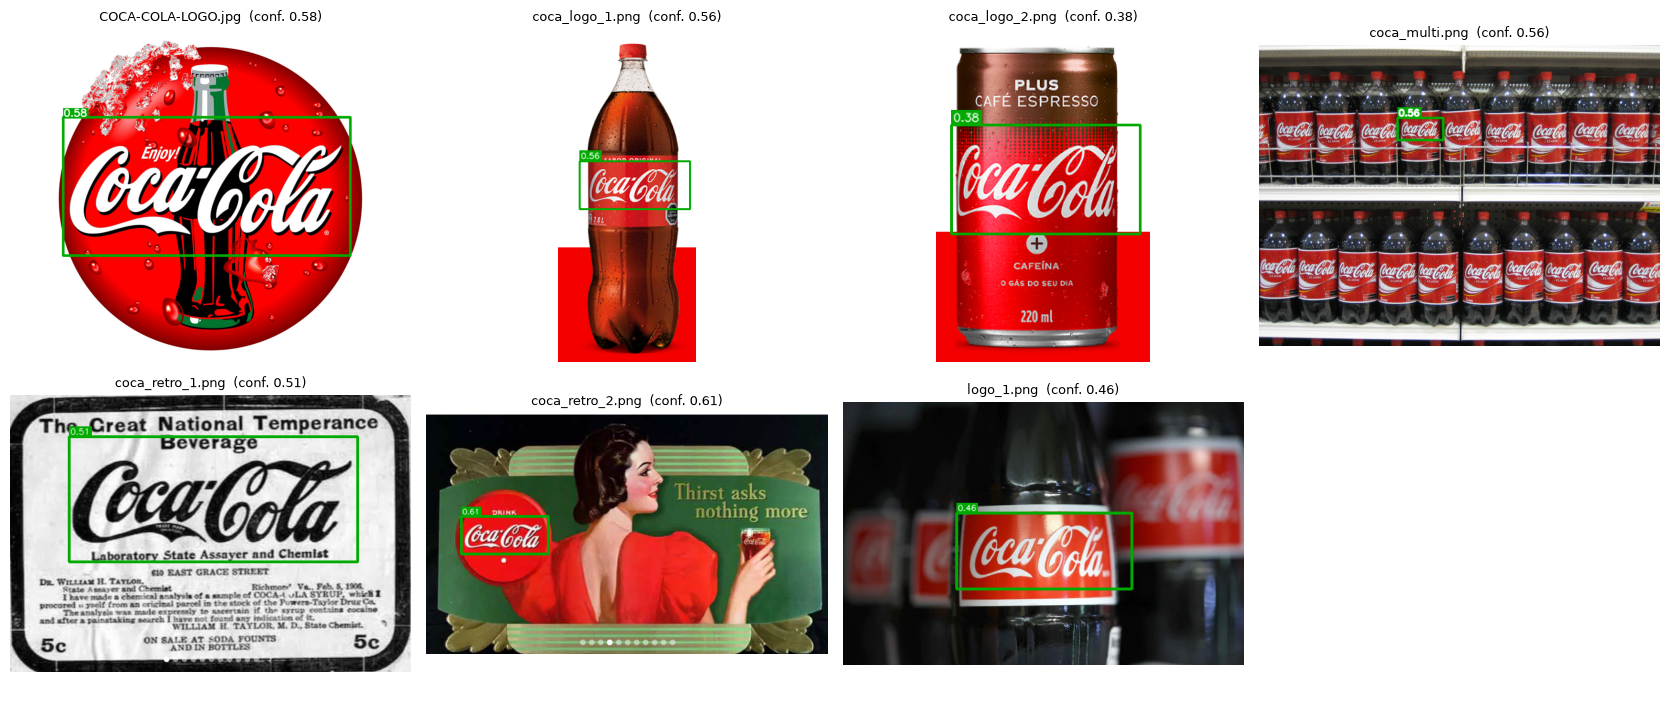

In [33]:
resultados_p1 = {}
vistas, titulos = [], []
print(f"{'imagen':22s} {'confianza':>10s} {'2da mejor':>10s} {'tiempo':>8s}")
for nombre, im in imagenes.items():
    t0 = time.time()
    dets = detectar_logos(im)
    dt = time.time() - t0
    resultados_p1[nombre] = dets
    segunda = dets[1]["score"] if len(dets) > 1 else 0.0
    print(f"{nombre:22s} {dets[0]['score']:10.2f} {segunda:10.2f} {dt:7.1f}s")
    vistas.append(dibujar(im, dets[:1]))
    titulos.append(f"{nombre}  (conf. {dets[0]['score']:.2f})")

grilla(vistas, titulos)

#### ¿Qué aporta la etapa 2? (ablación)

Para no afirmarlo sin evidencia, se compara, en cada imagen, la caja elegida **solo con la etapa 1** (mayor score de módulo de gradiente) contra la caja final (mayor confianza tras la verificación). Si difieren (IoU < 0.3) la etapa 2 está corrigiendo una elección errónea.

In [34]:
def iou(a, b):
    ax2, ay2, bx2, by2 = a[0] + a[2], a[1] + a[3], b[0] + b[2], b[1] + b[3]
    iw, ih = max(0, min(ax2, bx2) - max(a[0], b[0])), max(0, min(ay2, by2) - max(a[1], b[1]))
    i = iw * ih
    return i / (a[2] * a[3] + b[2] * b[3] - i)


print(f"{'imagen':22s} {'score etapa 1':>14s} {'score final':>12s}  etapa 1 sola elige la misma caja?")
for nombre, im in imagenes.items():
    b, s = etapa1(im, tpl, T1)
    top1_etapa1 = b[int(np.argmax(s))]
    final = resultados_p1[nombre][0]
    mismo = iou(top1_etapa1, final["box"]) >= 0.3
    print(f"{nombre:22s} {s.max():14.2f} {final['score']:12.2f}  {'si' if mismo else 'NO  -> la etapa 2 corrige'}")

imagen                  score etapa 1  score final  etapa 1 sola elige la misma caja?
COCA-COLA-LOGO.jpg               0.64         0.58  si
coca_logo_1.png                  0.56         0.56  si
coca_logo_2.png                  0.51         0.38  NO  -> la etapa 2 corrige
coca_multi.png                   0.63         0.56  si
coca_retro_1.png                 0.58         0.51  si
coca_retro_2.png                 0.72         0.61  si
logo_1.png                       0.46         0.46  si


**Conclusión de la Parte 1.** Con el mismo algoritmo y los mismos parámetros para las 7 imágenes, la detección de mayor confianza cae sobre el logo en todas, incluyendo los casos difíciles (logo blanco sobre rojo en `COCA-COLA-LOGO`, logo deformado en la lata, publicidad blanco y negro, logo desenfocado en `logo_1`).

Comparación de métodos:

| Método | Imágenes con detección correcta | Comentario |
|---|---|---|
| SIFT + RANSAC (1.A) | 1 / 7 | Solo funciona con el logo grande y nítido (`coca_retro_1`). |
| Template matching sobre bordes, solo etapa 1 | 6 / 7 | Falla en la lata (ver la ablación de abajo). |
| **Template matching de 2 etapas (1.B)** | **7 / 7** | La verificación por orientación elimina los falsos de la etapa 1. |

Nota: la caja es la del template completo, que incluye un pequeño margen blanco alrededor de las letras.

## Parte 2 : plantear y validar un algoritmo para múltiples detecciones en la imagen `coca_multi.png` con el mismo template del ítem 1

### Planteo

Para detectar **todas** las instancias se usa el mismo detector, pero en lugar de quedarse con el máximo se **conservan todas las detecciones verificadas cuya confianza supera un umbral** `UMBRAL_CONF = 0.30`, una vez aplicado el NMS (que evita contar dos veces el mismo logo en escalas vecinas).

Justificación del umbral: se elige mirando la **separación de las poblaciones de scores** (logos reales vs. candidatos espurios), no ajustando imagen por imagen. Se muestra a continuación para `coca_multi`:

Candidatos etapa 1 (tras NMS): 51 | verificados tras NMS: 45 | tiempo: 2.2s
Detecciones con confianza >= 0.3: 18


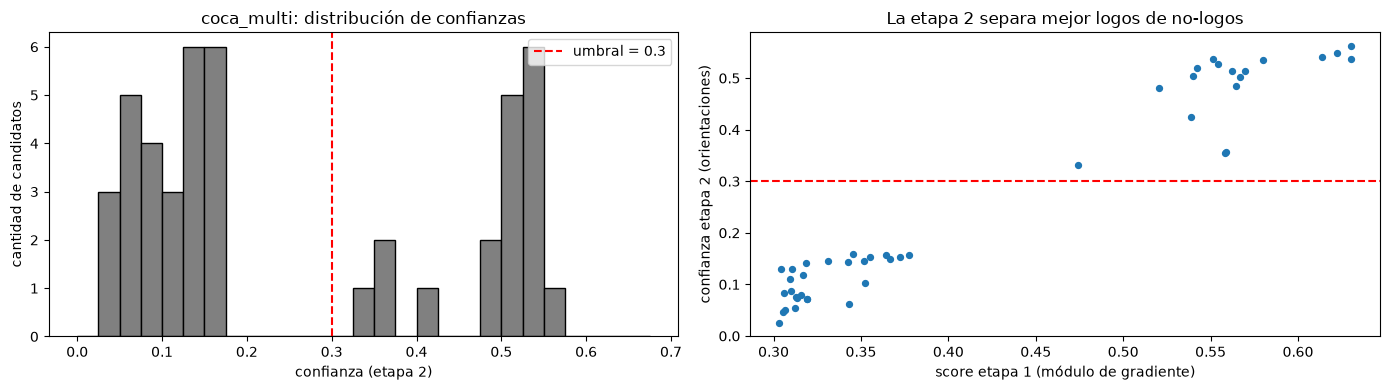

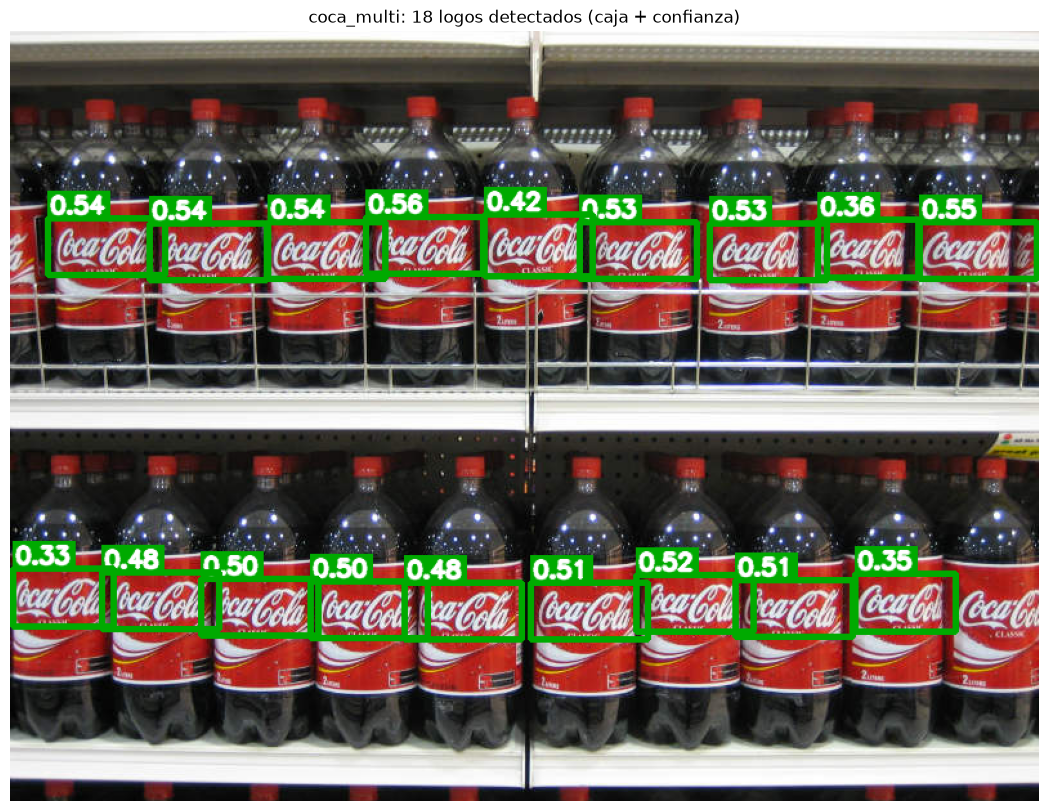

In [35]:
# Umbral de confianza que se usa para decidir si una detección es un logo (se justifica en la Parte 2)
UMBRAL_CONF = 0.30

multi = imagenes["coca_multi.png"]
t0 = time.time()
boxes1, sc1 = etapa1(multi, tpl, T1)               # candidatos de la etapa 1
dets_multi = etapa2(multi, boxes1, sc1, T2)        # verificados + NMS
print(f"Candidatos etapa 1 (tras NMS): {len(boxes1)} | verificados tras NMS: {len(dets_multi)} | tiempo: {time.time() - t0:.1f}s")

scores = np.array([d["score"] for d in dets_multi])
aceptadas = [d for d in dets_multi if d["score"] >= UMBRAL_CONF]
print(f"Detecciones con confianza >= {UMBRAL_CONF}: {len(aceptadas)}")

fig, axs = plt.subplots(1, 2, figsize=(14, 4))
axs[0].hist(scores, bins=np.arange(0, 0.7, 0.025), color="gray", edgecolor="black")
axs[0].axvline(UMBRAL_CONF, color="r", ls="--", label=f"umbral = {UMBRAL_CONF}")
axs[0].set_xlabel("confianza (etapa 2)"); axs[0].set_ylabel("cantidad de candidatos")
axs[0].set_title("coca_multi: distribución de confianzas"); axs[0].legend()

axs[1].scatter([d["score_cand"] for d in dets_multi], scores, s=18)
axs[1].axhline(UMBRAL_CONF, color="r", ls="--")
axs[1].set_xlabel("score etapa 1 (módulo de gradiente)"); axs[1].set_ylabel("confianza etapa 2 (orientaciones)")
axs[1].set_title("La etapa 2 separa mejor logos de no-logos")
plt.tight_layout(); plt.show()

plt.figure(figsize=(14, 10))
plt.imshow(dibujar(multi, dets_multi, umbral=UMBRAL_CONF))
plt.axis("off"); plt.title(f"coca_multi: {len(aceptadas)} logos detectados (caja + confianza)")
plt.show()

### Validación

Se plantean tres validaciones complementarias.

**(a) Sensibilidad al umbral en `coca_multi`.** Si el umbral estuviera "ajustado al ojo", el recuento cambiaría bruscamente al moverlo un poco.

In [36]:
print("umbral   detecciones en coca_multi")
for u in (0.15, 0.20, 0.25, 0.30, 0.35, 0.40, 0.45, 0.50):
    print(f"{u:5.2f}    {sum(d['score'] >= u for d in dets_multi):3d}")

umbral   detecciones en coca_multi
 0.15     24
 0.20     18
 0.25     18
 0.30     18
 0.35     17
 0.40     15
 0.45     14
 0.50     12


**(b) Ground truth sintético.** `coca_multi` no trae anotaciones, así que se genera un conjunto de escenas con verdad conocida: se pega el template a escalas aleatorias (70–280 px de ancho) sobre un fondo con textura, texto y círculos como distractores, más desenfoque y ruido. Se mide precisión y recall con IoU ≥ 0.5 contra la posición real.

*Limitación honesta:* es un caso más fácil que el real (el logo pegado es exactamente el template, sin perspectiva ni cambios de color), por lo que valida sobre todo el manejo de **escala, múltiples instancias y NMS**, no la robustez a las variaciones de las fotos reales.

escena 0: 8 logos reales | 8 detecciones | 8 correctas
escena 1: 8 logos reales | 8 detecciones | 8 correctas
escena 2: 8 logos reales | 8 detecciones | 8 correctas
escena 3: 8 logos reales | 8 detecciones | 8 correctas
escena 4: 8 logos reales | 8 detecciones | 8 correctas
escena 5: 8 logos reales | 8 detecciones | 8 correctas

Precisión = 1.00 | Recall = 1.00  (total: 48 logos)


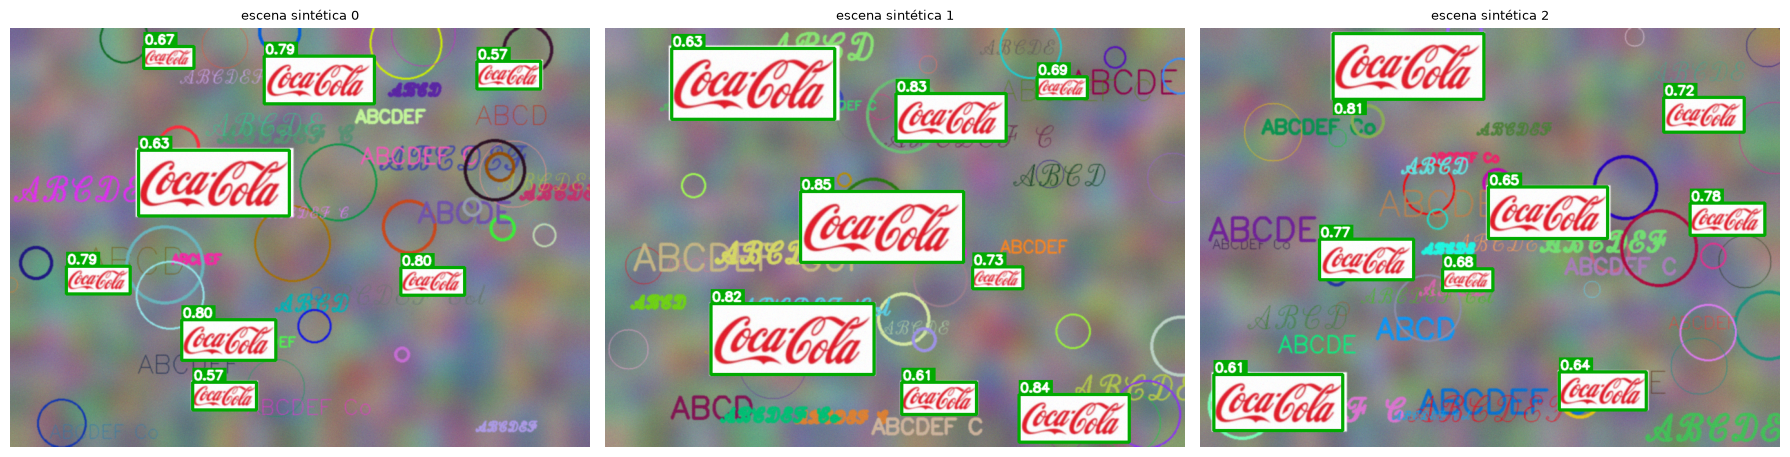

In [39]:
tpl_rgba = cv2.imread(str(TPL_PATH), cv2.IMREAD_UNCHANGED)


def escena_sintetica(seed, n=8, W=900, H=650):
    rng = np.random.default_rng(seed)
    bg = cv2.GaussianBlur(rng.integers(60, 200, (H // 20, W // 20, 3)).astype(np.uint8), (0, 0), 1)
    bg = cv2.resize(bg, (W, H), interpolation=cv2.INTER_CUBIC)
    for _ in range(25):                                           # distractores
        p = (int(rng.integers(0, W - 100)), int(rng.integers(30, H - 10)))
        fuente = cv2.FONT_HERSHEY_SCRIPT_COMPLEX if rng.random() < 0.5 else cv2.FONT_HERSHEY_SIMPLEX
        cv2.putText(bg, "ABCDEF Cola"[:int(rng.integers(4, 11))], p, fuente, float(rng.uniform(0.6, 2)),
                    tuple(int(v) for v in rng.integers(0, 255, 3)), int(rng.integers(1, 4)))
        cv2.circle(bg, (int(rng.integers(0, W)), int(rng.integers(0, H))), int(rng.integers(10, 60)),
                   tuple(int(v) for v in rng.integers(0, 255, 3)), int(rng.integers(1, 4)))
    gt, intentos = [], 0
    while len(gt) < n and intentos < 500:
        intentos += 1
        w = int(rng.uniform(70, 280)); h = int(round(w * tpl_rgba.shape[0] / tpl_rgba.shape[1]))
        x, y = int(rng.integers(0, W - w)), int(rng.integers(0, H - h))
        if any(abs(x - g[0]) < max(w, g[2]) and abs(y - g[1]) < max(h, g[3]) for g in gt):
            continue                                              # sin solapamiento
        t = cv2.resize(tpl_rgba, (w, h), interpolation=cv2.INTER_AREA)
        a = t[:, :, 3:4] / 255.0
        bg[y:y + h, x:x + w] = (t[:, :, :3] * a + bg[y:y + h, x:x + w] * (1 - a)).astype(np.uint8)
        gt.append((x, y, w, h))
    out = cv2.GaussianBlur(bg, (0, 0), 0.8).astype(np.float32) + rng.normal(0, 4, bg.shape)
    return np.clip(out, 0, 255).astype(np.uint8), gt


TP = FP = FN = 0
escenas = []
for seed in range(6):
    im_s, gt = escena_sintetica(seed)
    det = [d for d in detectar_logos(im_s) if d["score"] >= UMBRAL_CONF]
    usados, tp = set(), 0
    for d in det:
        mejor = max(range(len(gt)), key=lambda j: iou(d["box"], gt[j]))
        if iou(d["box"], gt[mejor]) >= 0.5 and mejor not in usados:
            usados.add(mejor); tp += 1
    TP += tp; FP += len(det) - tp; FN += len(gt) - tp
    escenas.append((im_s, det))
    print(f"escena {seed}: {len(gt)} logos reales | {len(det)} detecciones | {tp} correctas")

print(f"\nPrecisión = {TP / max(1, TP + FP):.2f} | Recall = {TP / max(1, TP + FN):.2f}  (total: {TP + FN} logos)")
grilla([dibujar(e[0], e[1]) for e in escenas[:3]], [f"escena sintética {i}" for i in range(3)], ncols=3, tam=(6, 4.5))

**(c) Inspección visual de `coca_multi`** (figura anterior). Cada caja está sobre un logo real; las de menor confianza (≈ 0.33–0.36) corresponden a logos parcialmente cortados o más inclinados. Entre los candidatos rechazados, el mayor llega solo a ≈ 0.16, es decir que el umbral 0.30 queda en una zona de muy poca densidad, con un hueco entre ≈ 0.16 y ≈ 0.33.

Sobre **(a)**: el recuento es constante (18) para umbrales entre 0.20 y 0.30 y recién cambia al bajarlo a 0.15 (entran candidatos espurios) o al subirlo a 0.35 o más (se pierden logos reales). Se adopta 0.30 y no 0.20 porque en otras imágenes (Parte 3) hay candidatos espurios de hasta ≈ 0.26, y 0.30 deja margen frente a ellos.

**Conclusión de la Parte 2.** Se detectan los logos visibles en los dos estantes, muy por encima del mínimo pedido. Quedan sin detectar los logos que aparecen apenas insinuados en los bordes izquierdo y derecho de la imagen (cortados), y las cajas de logos vecinos pueden solaparse un poco porque el NMS usa un IoU moderado (0.25) y el template incluye margen.

## Parte 3 : generalizar el algoritmo del ítem 2 para todas las imágenes 

### Generalización

El algoritmo de la Parte 2 **ya no depende de la imagen**: el ancho mínimo del logo es relativo al tamaño de la imagen, la pirámide se construye hasta el tamaño máximo posible, y el umbral de confianza es único. Se aplica entonces tal cual a las 7 imágenes (incluida `coca_multi`) y se muestran todas las detecciones con confianza ≥ `UMBRAL_CONF`.

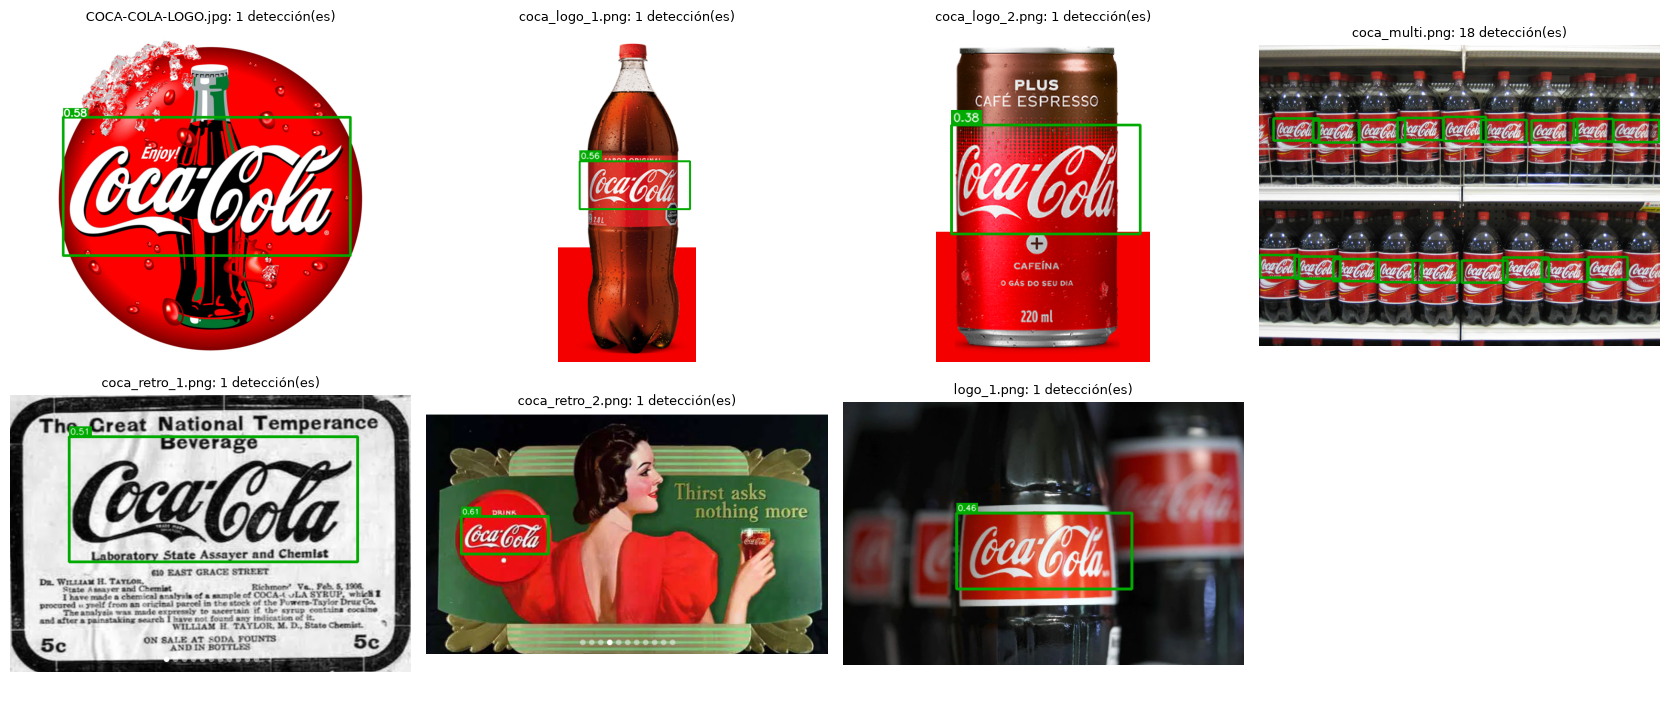

imagen                 detecciones  conf. mínima  mayor rechazada   tiempo
COCA-COLA-LOGO.jpg               1          0.58             0.15     2.1s
coca_logo_1.png                  1          0.56             0.19     1.6s
coca_logo_2.png                  1          0.38             0.26     1.4s
coca_multi.png                  18          0.33             0.16     2.1s
coca_retro_1.png                 1          0.51             0.23     2.1s
coca_retro_2.png                 1          0.61             0.24     2.2s
logo_1.png                       1          0.46             0.21     2.0s


In [40]:
resumen, vistas, titulos = [], [], []
for nombre, im in imagenes.items():
    t0 = time.time()
    dets = detectar_logos(im)
    ok = [d for d in dets if d["score"] >= UMBRAL_CONF]
    espurio_max = max([d["score"] for d in dets if d["score"] < UMBRAL_CONF], default=0.0)
    resumen.append((nombre, len(ok), min(d["score"] for d in ok) if ok else 0.0, espurio_max, time.time() - t0))
    vistas.append(dibujar(im, ok, etiquetas=(nombre != "coca_multi.png")))
    titulos.append(f"{nombre}: {len(ok)} detección(es)")

grilla(vistas, titulos)

print(f"{'imagen':22s} {'detecciones':>11s} {'conf. mínima':>13s} {'mayor rechazada':>16s} {'tiempo':>8s}")
for nombre, n, cmin, emax, dt in resumen:
    print(f"{nombre:22s} {n:11d} {cmin:13.2f} {emax:16.2f} {dt:7.1f}s")

### Conclusiones

- Un único algoritmo, sin parámetros específicos por imagen, detecta el logo en las 7 imágenes: **1 detección** en cada imagen de logo único y **18** en `coca_multi`, sin falsos positivos visibles con el umbral 0.30.
- El margen es amplio en casi todas las imágenes (columna *mayor rechazada* vs. *conf. mínima*). El más ajustado es `coca_logo_2` (lata, logo deformado por el cilindro): confianza ≈ 0.38 contra ≈ 0.26 del mejor candidato rechazado. Con imágenes todavía más difíciles convendría reconsiderar el umbral.
- **Qué aportó cada decisión de diseño:** (i) trabajar en el dominio del gradiente dio invariancia a polaridad y color; (ii) reescalar la *imagen* y no el template (suavizado proporcional) permitió cubrir escalas de 90 a 1200 px; (iii) anular ventanas sin bordes evitó scores espurios de 1.0 en zonas planas; (iv) la verificación por orientación corrigió la lata; (v) el NMS con *intersection-over-min-area* evitó dobles conteos entre escalas.
- **Limitaciones.** Los parámetros (`ancho_min_rel = 0.12`, umbral 0.30, tamaños de template) se fijaron una sola vez mirando este conjunto de 7 imágenes, por lo que no hay garantía de que generalicen a otros logos muy chicos (< 12 % del lado menor de la imagen), muy rotados o muy ocluidos: el método no es invariante a rotación, y solo tolera deformaciones moderadas de aspecto. Los logos cortados por el borde de la imagen se pierden. SIFT sería preferible para logos grandes con textura y rotación arbitraria, pero no sirvió para esta tipografía de trazo fino.
- **Posibles mejoras:** rotaciones en la pirámide, un detector de bordes multiescala (en lugar de Sobel + blur fijo), y calibrar el umbral con más imágenes anotadas.